# causal impact
- tfcausalimpact使用

In [47]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from causalimpact import CausalImpact


import sys
print('Python v{}'.format(sys.version))
print('pandas v{}'.format(pd.__version__))
print('numpy v{}'.format(np.__version__))
import matplotlib; print('matplotlib v{}'.format(matplotlib.__version__))
print('seaborn v{}'.format(sns.__version__))

import causalimpact; print('tfcausalimpact v{}'.format(causalimpact.__version__))

Python v3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]
pandas v2.2.0
numpy v1.26.4
matplotlib v3.10.9
seaborn v0.13.2
tfcausalimpact v0.0.18


In [2]:
# read data
# df = pd.read_csv('https://raw.githubusercontent.com/WillianFuks/tfcausalimpact/master/tests/fixtures/arma_data.csv')[['y', 'X']]

# causal impactのサンプル用に、意図的に介入後のデータを水増ししている（≒介入効果）
# df の 1列目の、70行目以降のすべての値に 5 を加える
# df.iloc[70:, 0] += 5

# pre_period = [0, 69]
# post_period = [70, 99]

In [3]:
# read data
# サンプルデータセットの作成

np.random.seed(42)

# 80日分の日付
days = pd.date_range(start="2024-09-01", periods=80, freq="D")

# 曜日 (0=月曜, 6=日曜)
dow = days.dayofweek

# 曜日ごとの効果（例：平日低め・土日高め）
weekday_effect = {0: -3, 1: -1, 2: 0, 3: -2, 4: -1, 5: 3, 6: 4}
effects = [weekday_effect[d] for d in dow]

# pre（1〜60日）：平均50 + 曜日効果
y_pre = np.random.normal(loc=50, scale=3, size=60) + np.array(effects[:60])

# post（61〜80日）：平均60 + 曜日効果
y_post = np.random.normal(loc=60, scale=3, size=20) + np.array(effects[60:])

# 共変量（pre/postとも同分布）
x_pre = np.random.normal(loc=30, scale=3, size=60)
x_post = np.random.normal(loc=30, scale=3, size=20)

# 結合
y = np.concatenate([y_pre, y_post])
x = np.concatenate([x_pre, x_post])

# データフレーム作成
df = pd.DataFrame({
    "date": days,
    "y": y,
    "x": x
})

In [4]:
print(df.head())
print(df.tail())
print(df.info())

        date          y          x
0 2024-09-01  55.490142  29.340984
1 2024-09-02  46.585207  31.071338
2 2024-09-03  50.943066  34.433682
3 2024-09-04  54.569090  28.445189
4 2024-09-05  47.297540  27.574519
         date          y          x
75 2024-11-15  61.465708  27.856946
76 2024-11-16  63.261141  35.597324
77 2024-11-17  63.102978  31.421499
78 2024-11-18  57.275282  26.426090
79 2024-11-19  53.037293  31.969661
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    80 non-null     datetime64[ns]
 1   y       80 non-null     float64       
 2   x       80 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 2.0 KB
None


In [5]:
# 土日祝

# 土日フラグ
df['is_holiday'] = df['date'].apply(lambda x: 1 if x.weekday()>=5 else 0)
# 平日祝日リスト
holidays = pd.to_datetime(['2024-09-16', '2024-09-23', '2024-10-14', '2024-11-04'])
# 祝日は1に上書き
df.loc[df['date'].isin(holidays), 'is_holiday'] = 1


In [6]:
df.head()

,date,y,x,is_holiday
0,2024-09-01,55.490142,29.340984,1
1,2024-09-02,46.585207,31.071338,0
2,2024-09-03,50.943066,34.433682,0
3,2024-09-04,54.569090,28.445189,0
4,2024-09-05,47.297540,27.574519,0


In [7]:
print(df.loc[60, "date"])

2024-10-31 00:00:00


In [8]:
# 介入日
base_date = pd.to_datetime("2024-10-31")

In [9]:
# 後続のグラフ表記に使用

# min,maxを取得
min_value = df['y'].min()
max_value = df['y'].max()

# オーダー（桁数）を取得
order_of_magnitude = int(np.floor(np.log10(max_value - min_value)))

# スケールを設定（オーダーに基づいて10の倍数に調整）
scale = 10 ** (order_of_magnitude - 1)

# min,max_limを設定
min_lim = np.floor(min_value / scale) * scale
max_lim = np.ceil(max_value / scale) * scale


# 桁数調整が不要なときは
# min_lim = min_value
# max_lim = max_value

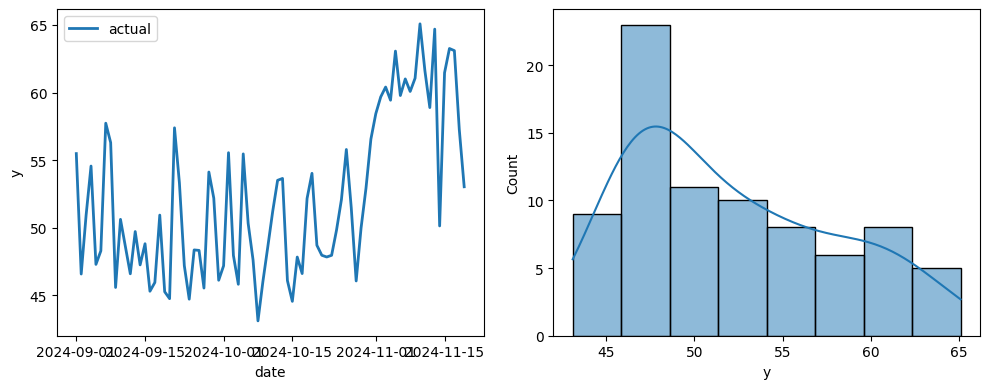

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(121)  # グラフ1行2列の1番目
sns.lineplot(data=df, x='date', y='y', linewidth=2, label='actual')

plt.subplot(122)  # グラフ1行2列の2番目
sns.histplot(data=df, x='y', kde=True)

plt.tight_layout()

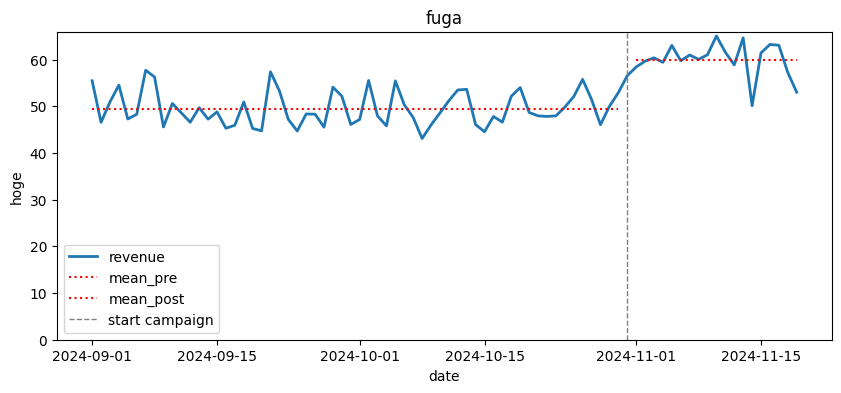

mean pre: 49.5
mean post: 59.9
diff: 10.4


In [11]:
# plot

plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='date', y='y', linewidth=2, label='revenue')
# sns.lineplot(data=df, x='date', y='x', linewidth=2, label='visitors')

# mean pre/post
mean_pre = df.query('date < @base_date')['y'].mean()
plt.hlines(xmin=df['date'].min(), xmax=base_date - pd.Timedelta(days=1), y=mean_pre, color="red", linestyles="dotted", linewidth=1.5, label="mean_pre")

mean_post = df.query('date >= @base_date')['y'].mean()
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df['date'].max(), y=mean_post, color="red", linestyles="dotted", linewidth=1.5, label="mean_post")

# base_date
plt.vlines(x=base_date, ymin=0, ymax=max_lim, colors="gray", linestyles="dashed", linewidth=1, label="start campaign")

# plt.ylim(min_lim, max_lim)
plt.ylim(0, max_lim)

plt.ylabel("hoge")
plt.title("fuga")
plt.legend(loc="best")
plt.show()


print(f"mean pre: {(mean_pre).round(1)}")
print(f"mean post: {(mean_post).round(1)}")
print(f"diff: {(mean_post - mean_pre).round(1)}")

# Parallel Trend Assumption 並行トレンド仮定の確認など

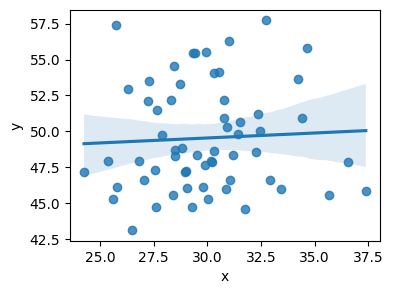

,x,y
x,1.000,0.052
y,0.052,1.000


In [46]:
# 並行トレンド仮定の簡易チェック
fig = plt.figure(figsize=(4,3))
sns.regplot(data=df.query('date < @base_date'), x='x', y='y')
plt.show()

df.query('date < @base_date')[['x', 'y']].corr().round(3)

In [13]:
# 共変量を使わない用のデータセット作成 
df_only_y = df[['date', 'y']].copy()


df_only_y.set_index('date', inplace=True)
df.set_index('date', inplace=True)

In [14]:
# pre,post_period
pre_start, pre_end = "2024-09-01", "2024-10-30"
post_start, post_end = "2024-10-31", "2024-11-19"

pre_start_date = pd.to_datetime(pre_start)
pre_end_date = pd.to_datetime(pre_end)
post_start_date = pd.to_datetime(post_start)
post_end_date = pd.to_datetime(post_end)

# 1 of 4 
- nseasons=none, cov=none

In [15]:
pre_period = [pre_start_date, pre_end_date]
post_period = [post_start_date, post_end_date]

ci = CausalImpact(df_only_y, pre_period, post_period, model_args={'fit_method': 'hmc'})

/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/tensorflow_probability/python/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


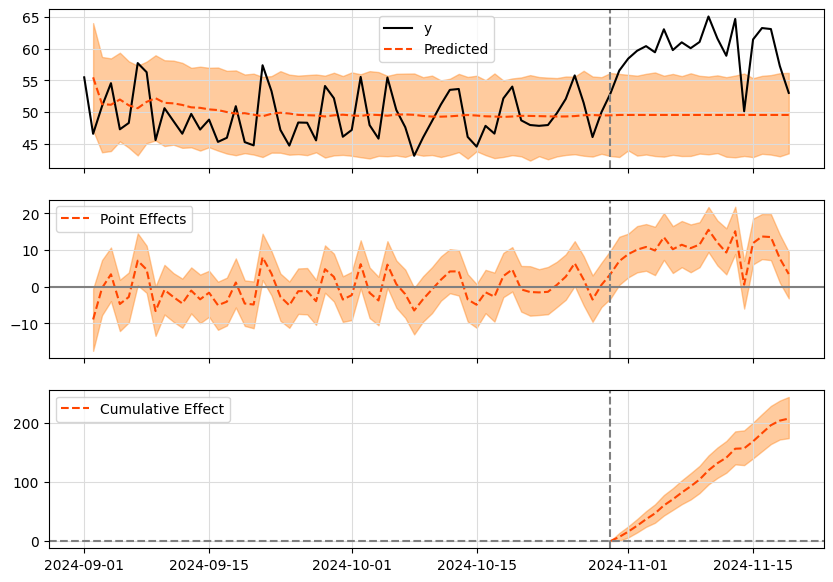

In [16]:
ci.plot()

In [17]:
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    59.91              1198.12
Prediction (s.d.)         49.56 (0.84)       991.17 (16.73)
95% CI                    [47.82, 51.1]      [956.39, 1021.97]

Absolute effect (s.d.)    10.35 (0.84)       206.94 (16.73)
95% CI                    [8.81, 12.09]      [176.14, 241.73]

Relative effect (s.d.)    20.88% (1.69%)     20.88% (1.69%)
95% CI                    [17.77%, 24.39%]   [17.77%, 24.39%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [18]:
# actualとpredictedを結合
df_pred = pd.concat([df_only_y.query('index<=@pre_period[1]').iloc[:, 0], ci.inferences[['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper', 'point_effects_means']]], axis='columns').reset_index()

# rename
df_pred = df_pred.set_axis(['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'residual'], axis='columns', copy=False)

# exclude post period
df_pred.dropna(inplace=True)

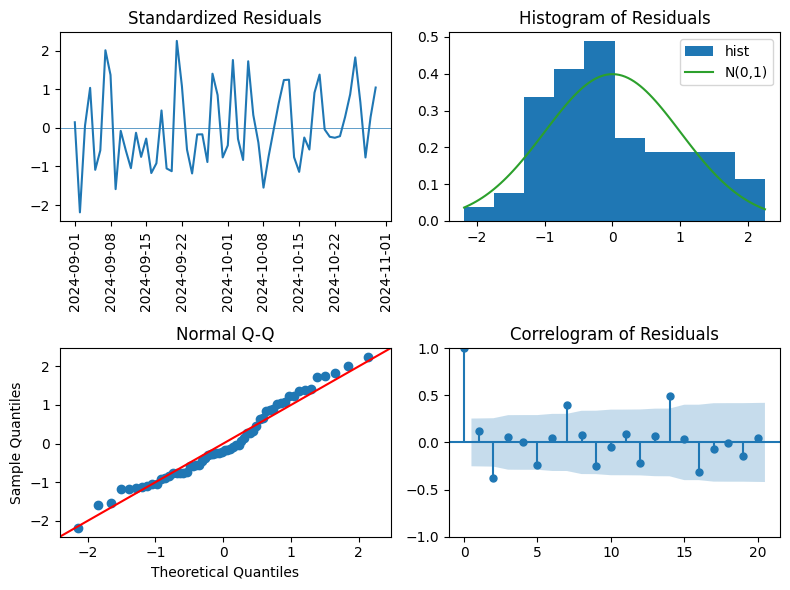

In [19]:
# モデルの予測精度検証: 残差の系列、ヒストグラム、正規Q-Qプロット、コレログラムをプロット
# 残差が正規分布しているか、自己相関の有無を確認。モデルが妥当であれば残差（説明しきれない部分）はホワイトノイズになる
from scipy.stats import zscore, norm
import statsmodels.api as sm

# 残差を標準化
standardized_residuals = zscore(df_pred['residual'])

# plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# 標準化された残差の系列
axes[0, 0].plot(df_pred['ds'], standardized_residuals)
axes[0,0].axhline(0, linestyle="solid", linewidth=0.5)
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title("Standardized Residuals")

# 標準化された残差のヒストグラムと正規分布
axes[0, 1].hist(standardized_residuals, density=True, label="hist")
norm_x = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
norm_y = norm.pdf(norm_x, loc=0, scale=1)
axes[0, 1].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].legend()

# 残差のQ-Qプロット
sm.qqplot(df_pred['residual'], fit=True, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q")

# 残差のコレログラム
sm.graphics.tsa.plot_acf(df_pred['residual'], lags=20, ax=axes[1, 1], title="Correlogram of Residuals")
axes[1, 1].set_title("Correlogram of Residuals")

plt.tight_layout()
plt.show()

In [20]:
# モデルの予測精度検証: 実績値と予測値の誤差をMAE, MAPE, RMSE, RMSPEで評価
import math
# MAE（平均絶対誤差）の計算関数
def mae(true, pred):
    return np.mean(np.abs(true - pred))
# MAPE（平均絶対誤差率）の計算関数
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100
# RMSE（（平均平方二乗誤差）の計算関数
def rmse(true, pred):
    return math.sqrt(np.mean((true - pred) ** 2))
# RMSPE（平均平方二乗誤差率）の計算関数
def rmspe(true, pred):
    return math.sqrt(np.mean(((true - pred) / true ) ** 2))

# numpy配列に変換
true_values = df_pred['y'].astype(float).to_numpy()
pred_values = df_pred['yhat'].astype(float).to_numpy()

print('MAE: {:.3f}'.format(mae(true_values, pred_values)))
print('MAPE: {:.3f}'.format(mape(true_values, pred_values)))
print('RMSE: {:.3f}'.format(rmse(true_values, pred_values)))
print('RMSPE: {:.3f}'.format(rmspe(true_values, pred_values)))

MAE: 3.281
MAPE: 6.646
RMSE: 3.858
RMSPE: 0.078


# 2 of 4
- nseasons=on, cov=none

In [21]:
pre_period = [pre_start_date, pre_end_date]
post_period = [post_start_date, post_end_date]

ci_nseasons = CausalImpact(df_only_y, pre_period, post_period, model_args={'fit_method': 'hmc', 'nseasons': 7})

/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/tensorflow_probability/python/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


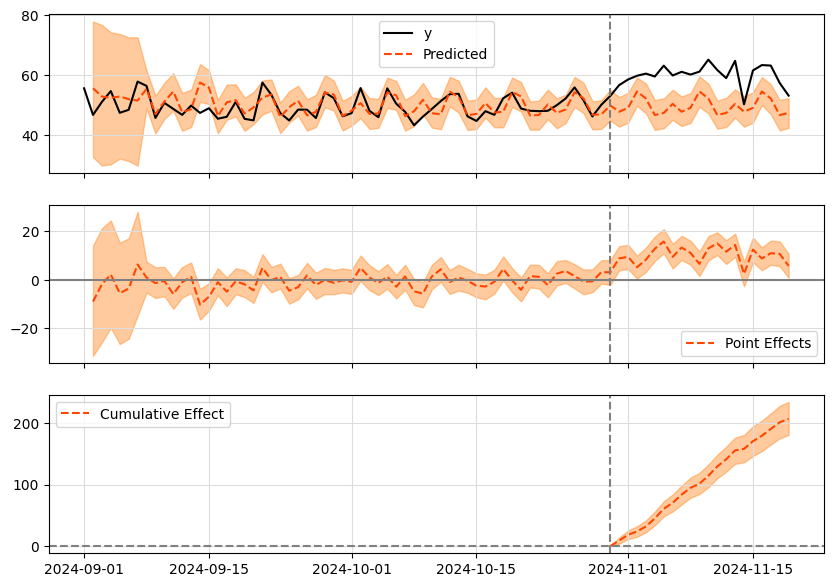

In [22]:
ci_nseasons.plot()

In [23]:
print(ci_nseasons.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    59.91              1198.12
Prediction (s.d.)         49.57 (0.62)       991.36 (12.44)
95% CI                    [48.34, 50.78]     [966.79, 1015.57]

Absolute effect (s.d.)    10.34 (0.62)       206.75 (12.44)
95% CI                    [9.13, 11.57]      [182.55, 231.33]

Relative effect (s.d.)    20.86% (1.26%)     20.86% (1.26%)
95% CI                    [18.41%, 23.33%]   [18.41%, 23.33%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [24]:
# actualとpredictedを結合
df_pred_nseasons = pd.concat([df_only_y.query('index<=@pre_period[1]').iloc[:, 0], ci_nseasons.inferences[['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper', 'point_effects_means']]], axis='columns').reset_index()

# rename
df_pred_nseasons = df_pred_nseasons.set_axis(['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'residual'], axis='columns', copy=False)

# exclude post period
df_pred_nseasons.dropna(inplace=True)

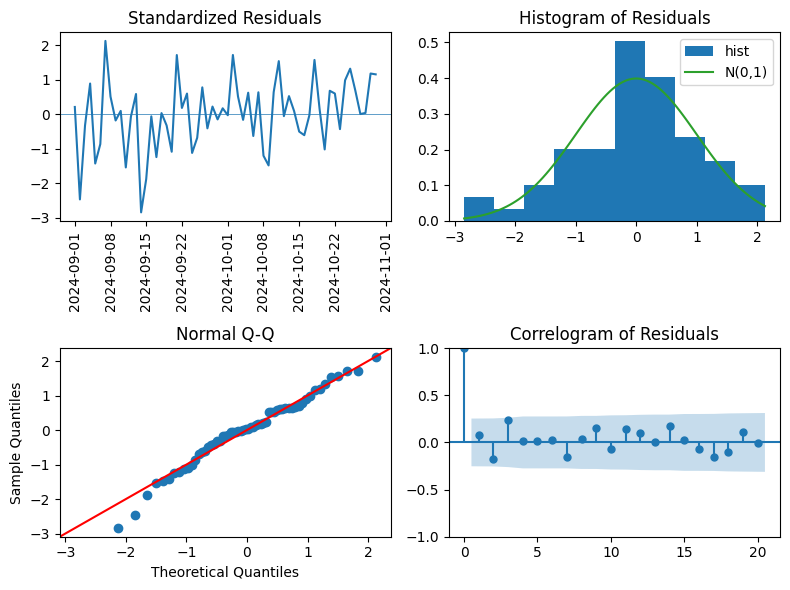

In [25]:
# モデルの予測精度検証: 残差の系列、ヒストグラム、正規Q-Qプロット、コレログラムをプロット
# 残差が正規分布しているか、自己相関の有無を確認。モデルが妥当であれば残差（説明しきれない部分）はホワイトノイズになる
from scipy.stats import zscore, norm
import statsmodels.api as sm

# 残差を標準化
standardized_residuals = zscore(df_pred_nseasons['residual'])

# plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# 標準化された残差の系列
axes[0, 0].plot(df_pred_nseasons['ds'], standardized_residuals)
axes[0,0].axhline(0, linestyle="solid", linewidth=0.5)
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title("Standardized Residuals")

# 標準化された残差のヒストグラムと正規分布
axes[0, 1].hist(standardized_residuals, density=True, label="hist")
norm_x = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
norm_y = norm.pdf(norm_x, loc=0, scale=1)
axes[0, 1].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].legend()

# 残差のQ-Qプロット
sm.qqplot(df_pred_nseasons['residual'], fit=True, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q")

# 残差のコレログラム
sm.graphics.tsa.plot_acf(df_pred_nseasons['residual'], lags=20, ax=axes[1, 1], title="Correlogram of Residuals")
axes[1, 1].set_title("Correlogram of Residuals")

plt.tight_layout()
plt.show()

In [26]:
# モデルの予測精度検証: 実績値と予測値の誤差をMAE, MAPE, RMSE, RMSPEで評価
import math
# MAE（平均絶対誤差）の計算関数
def mae(true, pred):
    return np.mean(np.abs(true - pred))
# MAPE（平均絶対誤差率）の計算関数
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100
# RMSE（（平均平方二乗誤差）の計算関数
def rmse(true, pred):
    return math.sqrt(np.mean((true - pred) ** 2))
# RMSPE（平均平方二乗誤差率）の計算関数
def rmspe(true, pred):
    return math.sqrt(np.mean(((true - pred) / true ) ** 2))

# numpy配列に変換
true_values_nseasons = df_pred_nseasons['y'].astype(float).to_numpy()
pred_values_nseasons = df_pred_nseasons['yhat'].astype(float).to_numpy()

print('MAE: {:.3f}'.format(mae(true_values_nseasons, pred_values_nseasons)))
print('MAPE: {:.3f}'.format(mape(true_values_nseasons, pred_values_nseasons)))
print('RMSE: {:.3f}'.format(rmse(true_values_nseasons, pred_values_nseasons)))
print('RMSPE: {:.3f}'.format(rmspe(true_values_nseasons, pred_values_nseasons)))

MAE: 2.582
MAPE: 5.275
RMSE: 3.397
RMSPE: 0.070


# 3 of 4
- nseasons=none, cov=on

In [27]:
pre_period = [pre_start_date, pre_end_date]
post_period = [post_start_date, post_end_date]

ci_cov = CausalImpact(df, pre_period, post_period, model_args={'fit_method': 'hmc'})

/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/tensorflow_probability/python/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


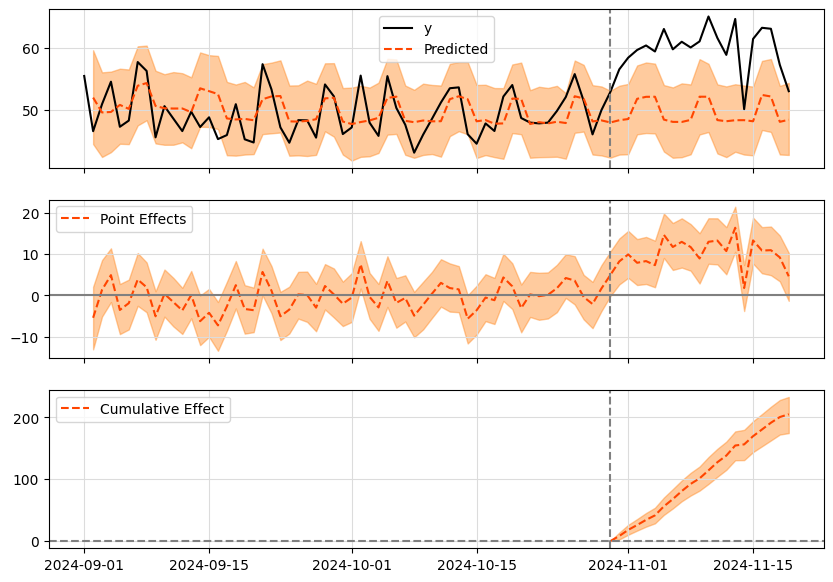

In [28]:
ci_cov.plot()

In [29]:
print(ci_cov.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    59.91              1198.12
Prediction (s.d.)         49.65 (0.74)       992.91 (14.83)
95% CI                    [48.15, 51.06]     [963.0, 1021.15]

Absolute effect (s.d.)    10.26 (0.74)       205.21 (14.83)
95% CI                    [8.85, 11.76]      [176.97, 235.12]

Relative effect (s.d.)    20.67% (1.49%)     20.67% (1.49%)
95% CI                    [17.82%, 23.68%]   [17.82%, 23.68%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [30]:
# actualとpredictedを結合
df_pred_cov = pd.concat([df.query('index<=@pre_period[1]').iloc[:, 0], ci_cov.inferences[['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper', 'point_effects_means']]], axis='columns').reset_index()

# rename
df_pred_cov = df_pred_cov.set_axis(['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'residual'], axis='columns', copy=False)

# exclude post period
df_pred_cov.dropna(inplace=True)

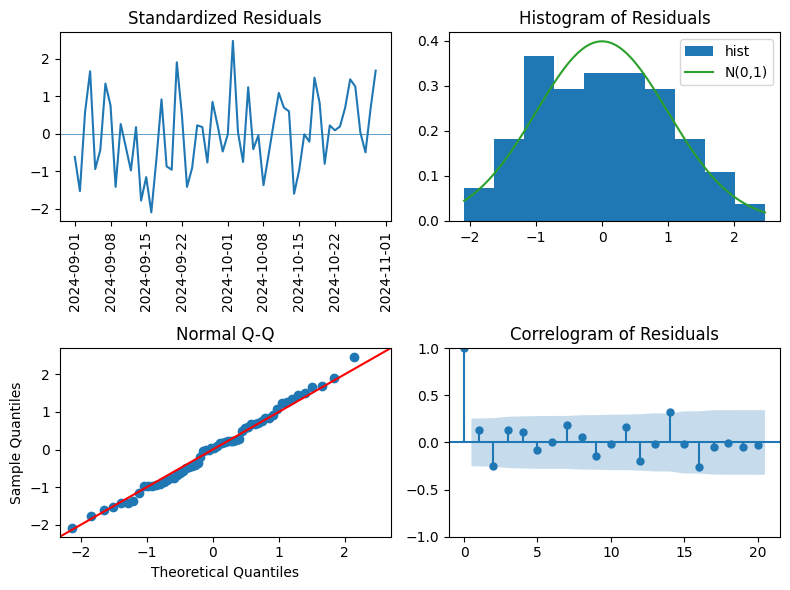

In [31]:
# モデルの予測精度検証: 残差の系列、ヒストグラム、正規Q-Qプロット、コレログラムをプロット
# 残差が正規分布しているか、自己相関の有無を確認。モデルが妥当であれば残差（説明しきれない部分）はホワイトノイズになる
from scipy.stats import zscore, norm
import statsmodels.api as sm

# 残差を標準化
standardized_residuals = zscore(df_pred_cov['residual'])

# plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# 標準化された残差の系列
axes[0, 0].plot(df_pred_cov['ds'], standardized_residuals)
axes[0,0].axhline(0, linestyle="solid", linewidth=0.5)
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title("Standardized Residuals")

# 標準化された残差のヒストグラムと正規分布
axes[0, 1].hist(standardized_residuals, density=True, label="hist")
norm_x = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
norm_y = norm.pdf(norm_x, loc=0, scale=1)
axes[0, 1].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].legend()

# 残差のQ-Qプロット
sm.qqplot(df_pred_cov['residual'], fit=True, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q")

# 残差のコレログラム
sm.graphics.tsa.plot_acf(df_pred_cov['residual'], lags=20, ax=axes[1, 1], title="Correlogram of Residuals")
axes[1, 1].set_title("Correlogram of Residuals")

plt.tight_layout()
plt.show()

In [32]:
# モデルの予測精度検証: 実績値と予測値の誤差をMAE, MAPE, RMSE, RMSPEで評価
import math
# MAE（平均絶対誤差）の計算関数
def mae(true, pred):
    return np.mean(np.abs(true - pred))
# MAPE（平均絶対誤差率）の計算関数
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100
# RMSE（（平均平方二乗誤差）の計算関数
def rmse(true, pred):
    return math.sqrt(np.mean((true - pred) ** 2))
# RMSPE（平均平方二乗誤差率）の計算関数
def rmspe(true, pred):
    return math.sqrt(np.mean(((true - pred) / true ) ** 2))

# numpy配列に変換
true_values_cov = df_pred_cov['y'].astype(float).to_numpy()
pred_values_cov = df_pred_cov['yhat'].astype(float).to_numpy()

print('MAE: {:.3f}'.format(mae(true_values_cov, pred_values_cov)))
print('MAPE: {:.3f}'.format(mape(true_values_cov, pred_values_cov)))
print('RMSE: {:.3f}'.format(rmse(true_values_cov, pred_values_cov)))
print('RMSPE: {:.3f}'.format(rmspe(true_values_cov, pred_values_cov)))

MAE: 2.662
MAPE: 5.408
RMSE: 3.272
RMSPE: 0.067


## loop 10 times

In [33]:
# # loop 10 times

# results_df = pd.DataFrame(columns = ['p_value', 'pred_avg', 'pred_lower_avg', 'pred_upper_avg', 'abs_avg', 'abs_lower_avg', 'abs_upper_avg', 'rel_avg', 'rel_lower_avg', 'rel_upper_avg'])

# for _ in range(10):
#     ci_cov = CausalImpact(df, pre_period, post_period, model_args={'fit_method': 'hmc'})
#     summary_data = ci_cov.summary_data
#     new_row = pd.DataFrame([{
#         'p_value': ci_cov.p_value,
#         'pred_avg': summary_data.loc['predicted', 'average'], 
#         'pred_lower_avg': summary_data.loc['predicted_lower', 'average'], 
#         'pred_upper_avg': summary_data.loc['predicted_upper', 'average'], 
#         'abs_avg': summary_data.loc['abs_effect', 'average'], 
#         'abs_lower_avg': summary_data.loc['abs_effect_lower', 'average'], 
#         'abs_upper_avg': summary_data.loc['abs_effect_upper', 'average'], 
#         'rel_avg': summary_data.loc['rel_effect', 'average'], 
#         'rel_lower_avg': summary_data.loc['rel_effect_lower', 'average'], 
#         'rel_upper_avg': summary_data.loc['rel_effect_upper', 'average']
#     }])
#     new_row = new_row.dropna(axis=1, how="all")  # drop columns where all values are NaN
#     results_df = pd.concat([results_df, new_row], ignore_index=True)

In [34]:
# results_df.round(3)

In [35]:
# results_df.mean().round(3)

# 4 of 4
- nseasons=on, cov=on

In [36]:
pre_period = [pre_start_date, pre_end_date]
post_period = [post_start_date, post_end_date]

ci_nseasons_cov = CausalImpact(df, pre_period, post_period, model_args={'fit_method': 'hmc', 'nseasons': 7})

/opt/homebrew/Caskroom/miniforge/base/envs/ci_env/lib/python3.11/site-packages/tensorflow_probability/python/mcmc/sample.py:339: UserWarning: Tracing all kernel results by default is deprecated. Set the `trace_fn` argument to None (the future default value) or an explicit callback that traces the values you are interested in.
  warnings.warn('Tracing all kernel results by default is deprecated. Set '


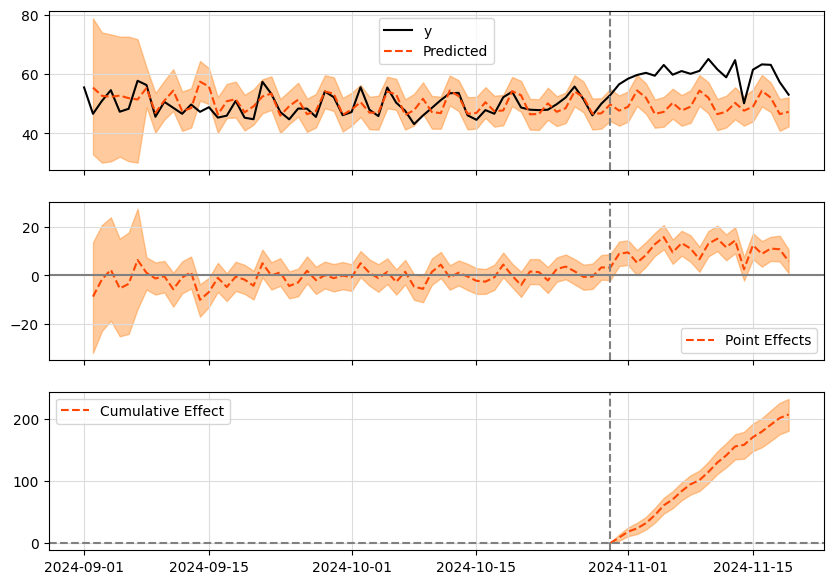

In [37]:
ci_nseasons_cov.plot()

In [38]:
print(ci_nseasons_cov.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    59.91              1198.12
Prediction (s.d.)         49.56 (0.64)       991.19 (12.9)
95% CI                    [48.29, 50.82]     [965.87, 1016.43]

Absolute effect (s.d.)    10.35 (0.64)       206.93 (12.9)
95% CI                    [9.08, 11.61]      [181.68, 232.25]

Relative effect (s.d.)    20.88% (1.3%)      20.88% (1.3%)
95% CI                    [18.33%, 23.43%]   [18.33%, 23.43%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [39]:
# actualとpredictedを結合
df_pred_nseasons_cov = pd.concat([df.query('index<=@pre_period[1]').iloc[:, 0], ci_nseasons_cov.inferences[['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper', 'point_effects_means']]], axis='columns').reset_index()

# rename
df_pred_nseasons_cov = df_pred_nseasons_cov.set_axis(['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'residual'], axis='columns', copy=False)

# exclude post period
df_pred_nseasons_cov.dropna(inplace=True)

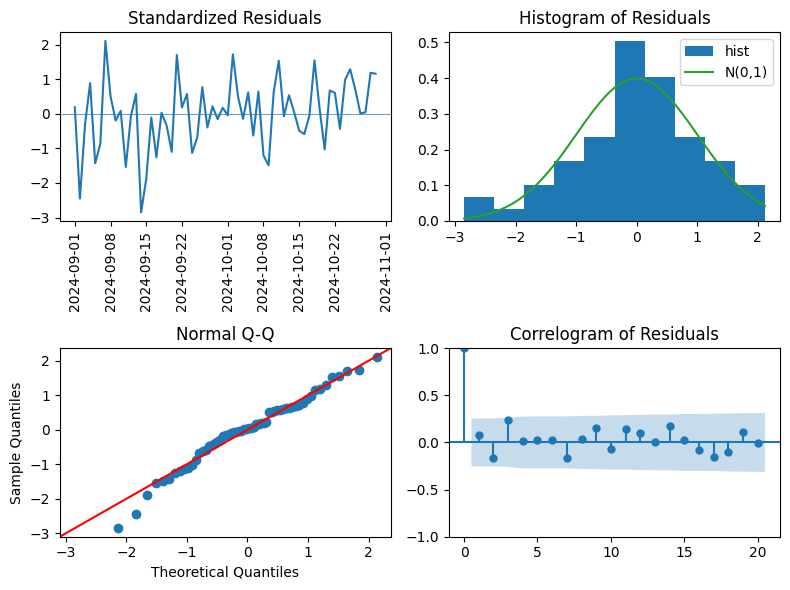

In [40]:
# モデルの予測精度検証: 残差の系列、ヒストグラム、正規Q-Qプロット、コレログラムをプロット
# 残差が正規分布しているか、自己相関の有無を確認。モデルが妥当であれば残差（説明しきれない部分）はホワイトノイズになる

from scipy.stats import zscore, norm
import statsmodels.api as sm

# 残差を標準化
standardized_residuals = zscore(df_pred_nseasons_cov['residual'])

# plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# 標準化された残差の系列
axes[0, 0].plot(df_pred_nseasons_cov['ds'], standardized_residuals)
axes[0,0].axhline(0, linestyle="solid", linewidth=0.5)
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title("Standardized Residuals")

# 標準化された残差のヒストグラムと正規分布
axes[0, 1].hist(standardized_residuals, density=True, label="hist")
norm_x = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
norm_y = norm.pdf(norm_x, loc=0, scale=1)
axes[0, 1].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
axes[0, 1].set_title("Histogram of Residuals")
axes[0, 1].legend()

# 残差のQ-Qプロット
sm.qqplot(df_pred_nseasons_cov['residual'], fit=True, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q")

# 残差のコレログラム
sm.graphics.tsa.plot_acf(df_pred_nseasons_cov['residual'], lags=20, ax=axes[1, 1], title="Correlogram of Residuals")
axes[1, 1].set_title("Correlogram of Residuals")

plt.tight_layout()
plt.show()

In [41]:
# モデルの予測精度検証: 実績値と予測値の誤差をMAE, MAPE, RMSE, RMSPEで評価
import math
# MAE（平均絶対誤差）の計算関数
def mae(true, pred):
    return np.mean(np.abs(true - pred))
# MAPE（平均絶対誤差率）の計算関数
def mape(true, pred):
    return np.mean(np.abs((true - pred) / true)) * 100
# RMSE（（平均平方二乗誤差）の計算関数
def rmse(true, pred):
    return math.sqrt(np.mean((true - pred) ** 2))
# RMSPE（平均平方二乗誤差率）の計算関数
def rmspe(true, pred):
    return math.sqrt(np.mean(((true - pred) / true ) ** 2))

# numpy配列に変換
true_values_nseasons_cov = df_pred_nseasons_cov['y'].astype(float).to_numpy()
pred_values_nseasons_cov = df_pred_nseasons_cov['yhat'].astype(float).to_numpy()

print('MAE: {:.3f}'.format(mae(true_values_nseasons_cov, pred_values_nseasons_cov)))
print('MAPE: {:.3f}'.format(mape(true_values_nseasons_cov, pred_values_nseasons_cov)))
print('RMSE: {:.3f}'.format(rmse(true_values_nseasons_cov, pred_values_nseasons_cov)))
print('RMSPE: {:.3f}'.format(rmspe(true_values_nseasons_cov, pred_values_nseasons_cov)))

MAE: 2.581
MAPE: 5.274
RMSE: 3.391
RMSPE: 0.070


# result all

In [42]:
print("nseasons=none, cov=none, MAPE={:.3f}, RMSPE={:.3f}".format(mape(true_values, pred_values), rmspe(true_values, pred_values)))
print(f"Posterior prob. pf a causal effect: {(1 - ci.p_value) * 100:.2f}%")
ci.summary_data.loc[['abs_effect', 'abs_effect_lower', 'abs_effect_upper'], ['average']]

nseasons=none, cov=none, MAPE=6.646, RMSPE=0.078
Posterior prob. pf a causal effect: 100.00%


,average
abs_effect,10.347248
abs_effect_lower,8.807070
abs_effect_upper,12.086482


In [43]:
print("nseasons=on, cov=none, MAPE={:.3f}, RMSPE={:.3f}".format(mape(true_values_nseasons, pred_values_nseasons), rmspe(true_values_nseasons, pred_values_nseasons)))
print(f"Posterior prob. pf a causal effect: {(1 - ci_nseasons.p_value) * 100:.2f}%")
ci_nseasons.summary_data.loc[['abs_effect', 'abs_effect_lower', 'abs_effect_upper'], ['average']]

nseasons=on, cov=none, MAPE=5.275, RMSPE=0.070
Posterior prob. pf a causal effect: 100.00%


,average
abs_effect,10.337627
abs_effect_lower,9.127464
abs_effect_upper,11.566414


In [44]:
print("nseasons=none, cov=on, MAPE={:.3f}, RMSPE={:.3f}".format(mape(true_values_cov, pred_values_cov), rmspe(true_values_cov, pred_values_cov)))
print(f"Posterior prob. pf a causal effect: {(1 - ci_cov.p_value) * 100:.2f}%")
ci_cov.summary_data.loc[['abs_effect', 'abs_effect_lower', 'abs_effect_upper'], ['average']]

nseasons=none, cov=on, MAPE=5.408, RMSPE=0.067
Posterior prob. pf a causal effect: 100.00%


,average
abs_effect,10.260529
abs_effect_lower,8.848303
abs_effect_upper,11.755790


In [45]:
print("nseasons=on, cov=on, MAPE={:.3f}, RMSPE={:.3f}".format(mape(true_values_nseasons_cov, pred_values_nseasons_cov), rmspe(true_values_nseasons_cov, pred_values_nseasons_cov)))
print(f"Posterior prob. pf a causal effect: {(1 - ci_nseasons_cov.p_value) * 100:.2f}%")
ci_nseasons_cov.summary_data.loc[['abs_effect', 'abs_effect_lower', 'abs_effect_upper'], ['average']]

nseasons=on, cov=on, MAPE=5.274, RMSPE=0.070
Posterior prob. pf a causal effect: 100.00%


,average
abs_effect,10.346306
abs_effect_lower,9.084185
abs_effect_upper,11.612480
